<a href="https://colab.research.google.com/github/Rouba-Os/AI-Course/blob/main/Assignment12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!apt-get install -y git
!git config --global user.email "rouba.osko@students.williscollege.com"
!git config --global user.name "Rouba-Os"

print("Git configured successfully")

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
git is already the newest version (1:2.34.1-1ubuntu1.17).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.
Git configured successfully


In [2]:
!git clone https://github.com/Rouba-Os/AI-Course.git
%cd AI-Course
!ls

Cloning into 'AI-Course'...
remote: Enumerating objects: 84, done.
remote: Counting objects: 100% (84/84), done.
remote: Compressing objects: 100% (82/82), done.
remote: Total 84 (delta 43), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (84/84), 1.43 MiB | 11.78 MiB/s, done.
Resolving deltas: 100% (43/43), done.
/content/AI-Course
AICourse.ipynb	    assignment2.ipynb  Assignment7.ipynb
Assignment11.ipynb  Assignment3.ipynb  Assignment8.ipynb
Assignment13.ipynb  Assignment4.ipynb  Assignment9.ipynb
Assignment14.ipynb  Assignment5.ipynb  git_github_exercise.ipynb
Assignment15.ipynb  Assignment6.ipynb  README.md


In [3]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


In [14]:
# Import Libraries
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

In [5]:
# Load Dataset
from tensorflow.keras.datasets import fashion_mnist

(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

print(train_images.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28)


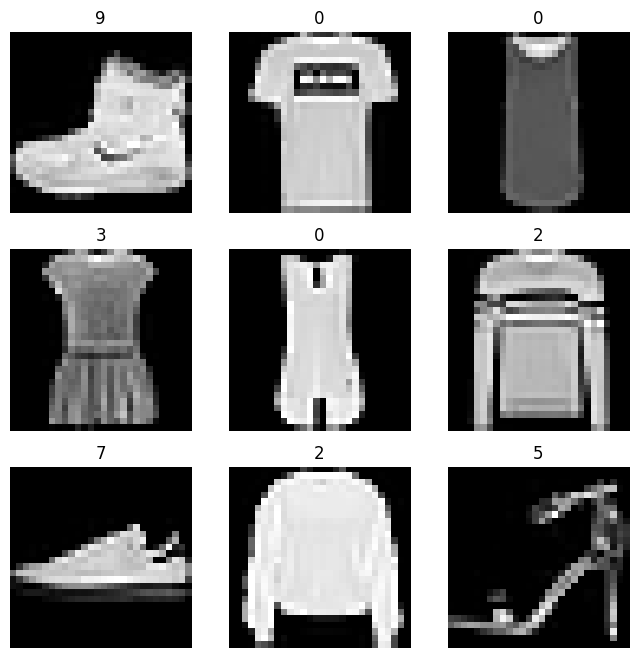

In [6]:
# Data Visualization
plt.figure(figsize=(8,8))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(train_images[i], cmap='gray')
    plt.title(train_labels[i])
    plt.axis('off')
plt.show()

In [7]:
# Data Preprocessing
## Normalization
train_images = train_images / 255.0
test_images = test_images / 255.0


In [8]:
# Build ANN Model
model = Sequential()

# Input Layer
model.add(Flatten(input_shape=(28,28)))

# Hidden Layer 1
model.add(Dense(128, activation='relu'))

# Hidden Layer 2
model.add(Dense(64, activation='relu'))

# Output Layer
model.add(Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [9]:
# Compile Model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [10]:
# Train Model
history = model.fit(
    train_images, train_labels,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8125 - loss: 0.5356 - val_accuracy: 0.8332 - val_loss: 0.4796
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8599 - loss: 0.3857 - val_accuracy: 0.8665 - val_loss: 0.3705
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8739 - loss: 0.3449 - val_accuracy: 0.8662 - val_loss: 0.3679
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8825 - loss: 0.3228 - val_accuracy: 0.8612 - val_loss: 0.3728
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8873 - loss: 0.3039 - val_accuracy: 0.8788 - val_loss: 0.3321
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8935 - loss: 0.2869 - val_accuracy: 0.8775 - val_loss: 0.3411
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8982 - loss: 0.2759 - val_accuracy: 0.8775 - val_loss: 0.3399
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9017 - loss: 0.2646 - val_accuracy: 0.

In [11]:
# Prediction
y_pred = np.argmax(model.predict(test_images), axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 997us/step


In [15]:
# Evaluation
## Accuracy
acc = accuracy_score(test_labels, y_pred)
print("Accuracy:", acc)

## Confusion Matrix
cm = confusion_matrix(test_labels, y_pred)
print("Confusion Matrix:\n", cm)

## Classification Report
print("\nClassification Report:\n")
print(classification_report(test_labels, y_pred))

Accuracy: 0.8726
Confusion Matrix:
 [[867   0  18  30   2   0  74   0   9   0]
 [  4 966   1  22   3   0   2   0   2   0]
 [ 14   0 833  21  58   0  58   0  16   0]
 [ 25   3   8 937   6   0  13   0   8   0]
 [  2   0 160  70 678   0  68   0  22   0]
 [  0   0   0   0   0 955   0  29   3  13]
 [180   1  97  34  48   0 611   0  29   0]
 [  0   0   0   0   0  16   0 973   1  10]
 [  3   0   0   6   2   1   1   5 982   0]
 [  0   0   0   1   0  10   1  63   1 924]]

Classification Report:

              precision    recall  f1-score   support

           0       0.79      0.87      0.83      1000
           1       1.00      0.97      0.98      1000
           2       0.75      0.83      0.79      1000
           3       0.84      0.94      0.88      1000
           4       0.85      0.68      0.75      1000
           5       0.97      0.95      0.96      1000
           6       0.74      0.61      0.67      1000
           7       0.91      0.97      0.94      1000
           8       0.

In [18]:
# Model Improvements

## Create a new improved ANN model (More Layers and Neurons)
model_improved = Sequential()

# Input Layer (flatten image from 28x28 → 784)
model_improved.add(Flatten(input_shape=(28,28)))

# Hidden Layer 1 (more neurons → better learning)
model_improved.add(Dense(256, activation='relu'))

# Hidden Layer 2 (extra layer → more complexity)
model_improved.add(Dense(128, activation='relu'))

# Output Layer (10 classes → softmax for probabilities)
model_improved.add(Dense(10, activation='softmax'))


## COMPILE MODEL (Use RMSprop optimizer instead of Adam)
model_improved.compile(
    optimizer='rmsprop',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## Train the improved model
history_improved = model_improved.fit(
    train_images, train_labels,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

## Predict all test images
y_pred2 = np.argmax(model_improved.predict(test_images), axis=1)

##  EVALUATION
acc2 = accuracy_score(test_labels, y_pred2)
print("\nImproved Model Accuracy:", acc2)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.8053 - loss: 0.5404 - val_accuracy: 0.8429 - val_loss: 0.4287
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8605 - loss: 0.3830 - val_accuracy: 0.8634 - val_loss: 0.3758
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8755 - loss: 0.3400 - val_accuracy: 0.8657 - val_loss: 0.3895
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8824 - loss: 0.3172 - val_accuracy: 0.8688 - val_loss: 0.3668
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8881 - loss: 0.3017 - val_accuracy: 0.8698 - val_loss: 0.3626
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8938 - loss: 0.2880 - val_accuracy: 0.8663 - val_loss: 0.3650
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8992 - loss: 0.2740 - val_accuracy: 0.8696 - val_loss: 0.3853
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9022 - loss: 0.2653 - val_accuracy: 0.

In [17]:
!touch Assignment12.ipynb
!git add Assignment12.ipynb
!git commit -m "Add Assignment 12"

[main f3e6ab7] Add Assignment 12
 1 file changed, 0 insertions(+), 0 deletions(-)
 create mode 100644 Assignment12.ipynb
